Imports

In [1]:
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import xgboost as xgb
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import gc
import json
import os
import time
import lightgbm as lgb
import random
from sklearn.utils.class_weight import compute_class_weight
import joblib

In [2]:
event_path = r"Data\BORG\instance_events-000000000000.json.gz"
usage_path = r"Data\BORG\instance_usage-000000000000.json.gz"

In [3]:
# Quick debug to see the actual 2019 Usage schema
usage_sample = pl.read_ndjson(usage_path, n_rows=5)
print(usage_sample.columns)
print(usage_sample.head(1))
event_sample = pl.read_ndjson(event_path, n_rows=5)
print(event_sample.columns)
print(event_sample.head(1))

['start_time', 'end_time', 'collection_id', 'instance_index', 'machine_id', 'alloc_collection_id', 'alloc_instance_index', 'collection_type', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction', 'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution']
shape: (1, 18)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ start_tim ┆ end_time  ┆ collectio ┆ instance_ ┆ … ┆ memory_ac ┆ sample_ra ┆ cpu_usage ┆ tail_cpu │
│ e         ┆ ---       ┆ n_id      ┆ index     ┆   ┆ cesses_pe ┆ te        ┆ _distribu ┆ _usage_d │
│ ---       ┆ str       ┆ ---       ┆ ---       ┆   ┆ r_instruc ┆ ---       ┆ tion      ┆ istribut │
│ str       ┆           ┆ str       ┆ str       ┆   ┆ tio…      ┆ f64       ┆ ---       ┆ ion      │
│           ┆           ┆           ┆           ┆   ┆ ---       ┆           ┆ list[f64] ┆ ---      │
│      

Mini block to test all features

In [7]:
labels = [4, 5, 7]
window_size = 60
# Full schema
event_schema = {
    "machine_id": pl.String, "time": pl.String, "type": pl.String,
    "priority": pl.String, "scheduling_class": pl.String,
    "missing_type": pl.String, "collection_type": pl.String,
    "collection_id": pl.String, "alloc_collection_id": pl.String,
    "instance_index": pl.String, "alloc_instance_index": pl.String,
    "resource_request": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "constraint": pl.List(pl.Struct([]))  # Just getting the list to count it
}
usage_schema = {
    "machine_id": pl.String, "start_time": pl.String, "end_time": pl.String,
    "collection_type": pl.String, "collection_id": pl.String, "alloc_collection_id": pl.String,
    "instance_index": pl.String, "alloc_instance_index": pl.String,
    "average_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "maximum_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "random_sample_usage": pl.Struct([pl.Field("cpus", pl.Float64)]),
    "assigned_memory": pl.Float64, "page_cache_memory": pl.Float64, 
    "cycles_per_instruction": pl.Float64, "memory_accesses_per_instruction": pl.Float64,
    "sample_rate": pl.Float64,
    "cpu_usage_distribution": pl.List(pl.Float64),
    "tail_cpu_usage_distribution": pl.List(pl.Float64)
}
print("Loading data...")
events = (pl.scan_ndjson(event_path, n_rows=5000000, schema=event_schema)
          .select([
              pl.col("machine_id").cast(pl.Float64), pl.col("time").cast(pl.Float64),
              pl.col("type").cast(pl.Int32).is_in(labels).cast(pl.Int8).alias("error_signal"),
              pl.col("priority").cast(pl.Float64).alias("ev_priority"),
              pl.col("scheduling_class").cast(pl.Float64).alias("ev_sched_class"),
              pl.col("missing_type").cast(pl.Float64).alias("ev_missing_type"),
              pl.col("collection_type").cast(pl.Float64).alias("ev_col_type"),
              pl.col("collection_id").cast(pl.Float64).alias("ev_col_id"),
              pl.col("alloc_collection_id").cast(pl.Float64).alias("ev_alloc_col_id"),
              pl.col("instance_index").cast(pl.Float64).alias("ev_inst_idx"),
              pl.col("alloc_instance_index").cast(pl.Float64).alias("ev_alloc_inst_idx"),
              pl.col("resource_request").struct.field("cpus").alias("ev_req_cpu"),
              pl.col("resource_request").struct.field("memory").alias("ev_req_mem"),
              pl.col("constraint").list.len().cast(pl.Float64).alias("ev_num_constraints")
          ])
          .sort("time"))
usage = (pl.scan_ndjson(usage_path, n_rows=5000000, schema=usage_schema)
         .select([
             pl.col("machine_id").cast(pl.Float64), pl.col("start_time").cast(pl.Float64).alias("time"),
             pl.col("collection_type").cast(pl.Float64).alias("us_col_type"),
             pl.col("collection_id").cast(pl.Float64).alias("us_col_id"),
             pl.col("alloc_collection_id").cast(pl.Float64).alias("us_alloc_col_id"),
             pl.col("instance_index").cast(pl.Float64).alias("us_inst_idx"),
             pl.col("alloc_instance_index").cast(pl.Float64).alias("us_alloc_inst_idx"),
             pl.col("average_usage").struct.field("cpus").alias("us_avg_cpu"),
             pl.col("average_usage").struct.field("memory").alias("us_avg_mem"),
             pl.col("maximum_usage").struct.field("cpus").alias("us_max_cpu"),
             pl.col("maximum_usage").struct.field("memory").alias("us_max_mem"),
             pl.col("random_sample_usage").struct.field("cpus").alias("us_rand_cpu"),
             pl.col("assigned_memory").alias("us_assigned_mem"),
             pl.col("page_cache_memory").alias("us_page_cache_mem"),
             pl.col("cycles_per_instruction").alias("us_cpi"),
             pl.col("memory_accesses_per_instruction").alias("us_mapi"),
             pl.col("sample_rate").alias("us_sample_rate"),
             pl.col("cpu_usage_distribution").list.last().cast(pl.Float64).alias("us_cpu_dist_tail"),
             pl.col("tail_cpu_usage_distribution").list.last().cast(pl.Float64).alias("us_cpu_tail_dist_tail")
         ])
         .sort("time"))
print("Joining data...")
df_raw = events.join_asof(usage, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)


print("Joining data...")
df_raw = events.join_asof(usage, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)
features = [
    "ev_priority", "ev_sched_class", "ev_missing_type", "ev_col_type", 
    "ev_col_id", "ev_alloc_col_id", "ev_inst_idx", "ev_alloc_inst_idx",
    "ev_req_cpu", "ev_req_mem", "ev_num_constraints",
    "us_col_type", "us_col_id", "us_alloc_col_id", "us_inst_idx", "us_alloc_inst_idx",
    "us_avg_cpu", "us_avg_mem", "us_max_cpu", "us_max_mem", "us_rand_cpu",
    "us_assigned_mem", "us_page_cache_mem", "us_cpi", "us_mapi", "us_sample_rate",
    "us_cpu_dist_tail", "us_cpu_tail_dist_tail"
]

Loading data...
Joining data...


C:\Users\sabbu\AppData\Local\Temp\ipykernel_26352\2688008180.py:67: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_raw = events.join_asof(usage, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)


Joining data...


C:\Users\sabbu\AppData\Local\Temp\ipykernel_26352\2688008180.py:71: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_raw = events.join_asof(usage, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)


In [43]:
print("Resampling...")
df_grid = df_raw.with_columns((pl.col("time") // 300_000_000).cast(pl.Int64).alias("time_bucket"))
df_grid = df_grid.group_by(["machine_id", "time_bucket"]).agg(
    [pl.col("error_signal").max()] + [pl.col(f).mean() for f in features]
).sort(["machine_id", "time_bucket"]).fill_null(0.0)
print("Extracting sequences...")
def extract_sequences(df, window_size):
    groups = df.group_by("machine_id")
    X, y = [], []
    MAX_GAP = 24
    for _, group in groups:
        buckets = group.select("time_bucket").to_numpy().flatten()
        if len(buckets) < window_size: continue
        vals = group.select(features).to_numpy()
        signals = group.select("error_signal").to_numpy().flatten()
        
        chunks = []
        c_b, c_v, c_s = [buckets[0]], [vals[0]], [signals[0]]
        for i in range(1, len(buckets)):
            if buckets[i] - buckets[i-1] > MAX_GAP:
                chunks.append((c_b, c_v, c_s))
                c_b, c_v, c_s = [buckets[i]], [vals[i]], [signals[i]]
            else:
                c_b.append(buckets[i])
                c_v.append(vals[i])
                c_s.append(signals[i])
        chunks.append((c_b, c_v, c_s))
        
        for c_b_chunk, c_v_chunk, c_s_chunk in chunks:
            if len(c_b_chunk) == 0: continue
            min_b, max_b = int(c_b_chunk[0]), int(c_b_chunk[-1])
            length = max_b - min_b + 1
            if length < window_size + 6 or length > 50000: continue
            
            dense_vals = np.zeros((length, len(features)), dtype='float32')
            dense_signals = np.zeros(length, dtype='int8')
            
            curr_v, idx = c_v_chunk[0], 0
            for b in range(length):
                if idx < len(c_b_chunk) and c_b_chunk[idx] == min_b + b:
                    curr_v = c_v_chunk[idx]
                    dense_signals[b] = c_s_chunk[idx]
                    idx += 1
                dense_vals[b] = curr_v
                
            for T in range(window_size, length - 5, 2):
                X.append(dense_vals[T - window_size : T])
                y.append(1 if dense_signals[T : T + 6].sum() > 0 else 0)
    return np.array(X), np.array(y)
X_all, y_all = extract_sequences(df_grid, window_size)
print(f"Extracted {len(X_all)} sequences")
X_flat = X_all.reshape(X_all.shape[0], -1)
pos_weight = (len(y_all) - sum(y_all)) / sum(y_all) if sum(y_all) > 0 else 1.0
print("Training XGBoost...")
m = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=pos_weight, n_estimators=50, max_depth=4)
m.fit(X_flat, y_all)
raw_importances = m.feature_importances_
importances_2d = raw_importances.reshape(window_size, len(features))
overall_importance = importances_2d.sum(axis=0)
if overall_importance.sum() > 0:
    overall_importance = (overall_importance / overall_importance.sum()) * 100
importance_dict = dict(zip(features, overall_importance))
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
with open("feature_importances_all.txt", "w") as f:
    for name, imp in sorted_importance:
        f.write(f"{name}: {imp:.2f}%\n")
print("Done!")

Resampling...
Extracting sequences...
Extracted 44612 sequences
Training XGBoost...


C:\Users\sabbu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [10:45:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Done!


End of mini test

In [4]:
def extract_metric(col_name, key):
    extracted = (
        pl.col(col_name)
        .cast(pl.Utf8)
        .str.extract(rf"'{key}':\s(*[\d\.eE-]+)", 1)
        .cast(pl.Float64, strict=False)
    )
    
    return pl.coalesce([extracted, pl.col(col_name).cast(pl.Float64, strict=False)]).fill_null(0.0)

In [5]:
print("1. Loading raw data with labels [4, 5, 7] and 6 Features...")
event_schema = {
    "machine_id": pl.String, "time": pl.String, "type": pl.String,
    "priority": pl.String, "missing_type": pl.String,
    "resource_request": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "constraint": pl.List(pl.Struct([])) 
}
usage_schema = {
    "machine_id": pl.String, "start_time": pl.String,
    "average_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "maximum_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "random_sample_usage": pl.Struct([pl.Field("cpus", pl.Float64)]),
    "assigned_memory": pl.Float64, "page_cache_memory": pl.Float64, 
    "cycles_per_instruction": pl.Float64, "memory_accesses_per_instruction": pl.Float64,
    "sample_rate": pl.Float64,
    "cpu_usage_distribution": pl.List(pl.Float64),
    "tail_cpu_usage_distribution": pl.List(pl.Float64)
}

print("Loading and Parsing Raw JSONs...")
failure_labels = [4, 5, 7]

# Load Events (Priority, Demands, Missing Types, Constraints)
events = (pl.scan_ndjson(event_path, schema=event_schema)
          .select([
              pl.col("machine_id").cast(pl.Float64), 
              pl.col("time").cast(pl.Float64),
              pl.col("type").cast(pl.Int32).is_in(failure_labels).cast(pl.Int8).alias("error_signal"),
              pl.col("priority").cast(pl.Float64).alias("ev_priority"),
              pl.col("missing_type").cast(pl.Float64).alias("ev_missing_type"),
              pl.col("resource_request").struct.field("cpus").alias("ev_req_cpu"),
              pl.col("resource_request").struct.field("memory").alias("ev_req_mem"),
              pl.col("constraint").list.len().cast(pl.Float64).alias("ev_num_constraints")
          ])
          .sort("time"))

# Load Usage (Sample Rate, MAPI, Cache, Averages, Maxes, Distributions)
usage = (pl.scan_ndjson(usage_path, schema=usage_schema)
         .select([
             pl.col("machine_id").cast(pl.Float64), 
             pl.col("start_time").cast(pl.Float64).alias("time"),
             pl.col("sample_rate").alias("us_sample_rate"),
             pl.col("page_cache_memory").alias("us_page_cache_mem"),
             pl.col("memory_accesses_per_instruction").alias("us_mapi"),
             pl.col("average_usage").struct.field("cpus").alias("us_avg_cpu"),
             pl.col("average_usage").struct.field("memory").alias("us_avg_mem"),
             pl.col("maximum_usage").struct.field("cpus").alias("us_max_cpu"),
             pl.col("maximum_usage").struct.field("memory").alias("us_max_mem"),
             pl.col("cpu_usage_distribution").list.last().cast(pl.Float64).alias("us_cpu_dist_tail"),
             pl.col("random_sample_usage").struct.field("cpus").alias("us_rand_cpu"),
             pl.col("cycles_per_instruction").alias("us_cpi"),
             pl.col("assigned_memory").alias("us_assigned_mem"),
             pl.col("tail_cpu_usage_distribution").list.last().cast(pl.Float64).alias("us_cpu_tail_dist_tail")
         ])
         .sort("time"))

df_raw = events.join_asof(usage, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)

print("2. Resampling to strict 5-minute time grid...")
features = [
    'ev_req_cpu', 
    'ev_req_mem', 
    'us_sample_rate', 
    'us_page_cache_mem', 
    'us_avg_mem',
    'us_max_cpu',
    'us_avg_cpu',
    'us_cpi'
]

df_grid = df_raw.with_columns(
    (pl.col("time") // 50_000_000).cast(pl.Int64).alias("time_bucket")
)

# Dynamically aggregate all 9 features
df_grid = df_grid.group_by(["machine_id", "time_bucket"]).agg(
    [pl.col("error_signal").max()] + [pl.col(f).mean() for f in features]
).sort(["machine_id", "time_bucket"]).fill_null(0.0)

print("3. Performing per-machine temporal split (70% train / 30% test)...")
train_rows, test_rows = [], []
for _, group in df_grid.group_by("machine_id"):
    group = group.sort("time_bucket")
    cut = int(len(group) * 0.70)
    train_rows.append(group.slice(0, cut))
    test_rows.append(group.slice(cut))
df_train_grid = pl.concat(train_rows)
df_test_grid = pl.concat(test_rows)

del df_raw, df_grid
gc.collect()

print("4. Applying StandardScaler...")
scaler = StandardScaler()

df_train_scaled_vals = scaler.fit_transform(df_train_grid.select(features).to_numpy())
df_train_grid = df_train_grid.with_columns([
    pl.Series(name=features[i], values=df_train_scaled_vals[:, i]) for i in range(len(features))
])

df_test_scaled_vals = scaler.transform(df_test_grid.select(features).to_numpy())
df_test_grid = df_test_grid.with_columns([
    pl.Series(name=features[i], values=df_test_scaled_vals[:, i]) for i in range(len(features))
])

print("5. Extracting sequences (with contiguity gap checks)...")
def extract_sequences_from_df(df, window_size=60):
    groups = df.group_by("machine_id")
    X, y = [], []
    MAX_GAP = 24
    
    for _, group in groups:
        buckets = group.select("time_bucket").to_numpy().flatten()
        if len(buckets) == 0: 
            continue
            
        vals = group.select(features).to_numpy()
        signals = group.select("error_signal").to_numpy().flatten()
        
        chunks = []
        current_chunk_buckets = [buckets[0]]
        current_chunk_vals = [vals[0]]
        current_chunk_signals = [signals[0]]
        
        for i in range(1, len(buckets)):
            gap = buckets[i] - buckets[i-1]
            if gap > MAX_GAP:
                chunks.append((current_chunk_buckets, current_chunk_vals, current_chunk_signals))
                current_chunk_buckets = [buckets[i]]
                current_chunk_vals = [vals[i]]
                current_chunk_signals = [signals[i]]
            else:
                current_chunk_buckets.append(buckets[i])
                current_chunk_vals.append(vals[i])
                current_chunk_signals.append(signals[i])
                
        chunks.append((current_chunk_buckets, current_chunk_vals, current_chunk_signals))
        
        for c_buckets, c_vals, c_signals in chunks:
            if len(c_buckets) == 0: continue
            min_b = int(c_buckets[0])
            max_b = int(c_buckets[-1])
            
            if max_b - min_b + 1 < window_size + 6:
                continue
                
            length = max_b - min_b + 1
            if length > 100000: 
                continue
                
            dense_vals = np.zeros((length, len(features)), dtype='float32')
            dense_signals = np.zeros(length, dtype='int8')
            
            current_val = c_vals[0]
            idx = 0
            for b in range(length):
                actual_bucket = min_b + b
                if idx < len(c_buckets) and c_buckets[idx] == actual_bucket:
                    current_val = c_vals[idx]
                    dense_signals[b] = c_signals[idx]
                    idx += 1
                dense_vals[b] = current_val
                
            for T in range(window_size, length - 6):
                X.append(dense_vals[T - window_size : T])
                y.append(1 if dense_signals[T : T + 6].sum() > 0 else 0)
                
    return np.array(X), np.array(y)

window_size = 24

X_train, y_train = extract_sequences_from_df(df_train_grid, window_size)
print(f"\nTrain shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Train Positive Rate: {y_train.mean():.4f}")

X_test, y_test = extract_sequences_from_df(df_test_grid, window_size)
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")
print(f"Test Positive Rate: {y_test.mean():.4f}")
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

pos_rate = y_train.mean()
if pos_rate > 0:
    class_weights = {0: pos_rate, 1: (1.0 - pos_rate)}
else:
    class_weights = {0: 0.5, 1: 0.5}
print(f"Computed Class Weights: {class_weights}")

del df_train_grid, df_test_grid
gc.collect()


1. Loading raw data with labels [4, 5, 7] and 6 Features...
Loading and Parsing Raw JSONs...


C:\Users\sabbu\AppData\Local\Temp\ipykernel_24076\108147328.py:57: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_raw = events.join_asof(usage, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)


2. Resampling to strict 5-minute time grid...
3. Performing per-machine temporal split (70% train / 30% test)...
4. Applying StandardScaler...
5. Extracting sequences (with contiguity gap checks)...

Train shapes: X=(8769164, 24, 8), y=(8769164,)
Train Positive Rate: 0.1811
Test shapes: X=(3588675, 24, 8), y=(3588675,)
Test Positive Rate: 0.2008
Computed Class Weights: {0: np.float64(0.18113015106115019), 1: np.float64(0.8188698489388498)}


0

1. Loading data for 12-hour diagnostics (preserving raw types)...


C:\Users\sabbu\AppData\Local\Temp\ipykernel_13452\2061801470.py:36: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_diag_raw = events_diag.join_asof(usage_diag, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)


2. Resampling to 5-minute grid...
3. Extracting 12-hour diagnostic sequences (144 steps)...
Extracted 152582 sequences of shape (144, 6)
4. Plotting trajectories...


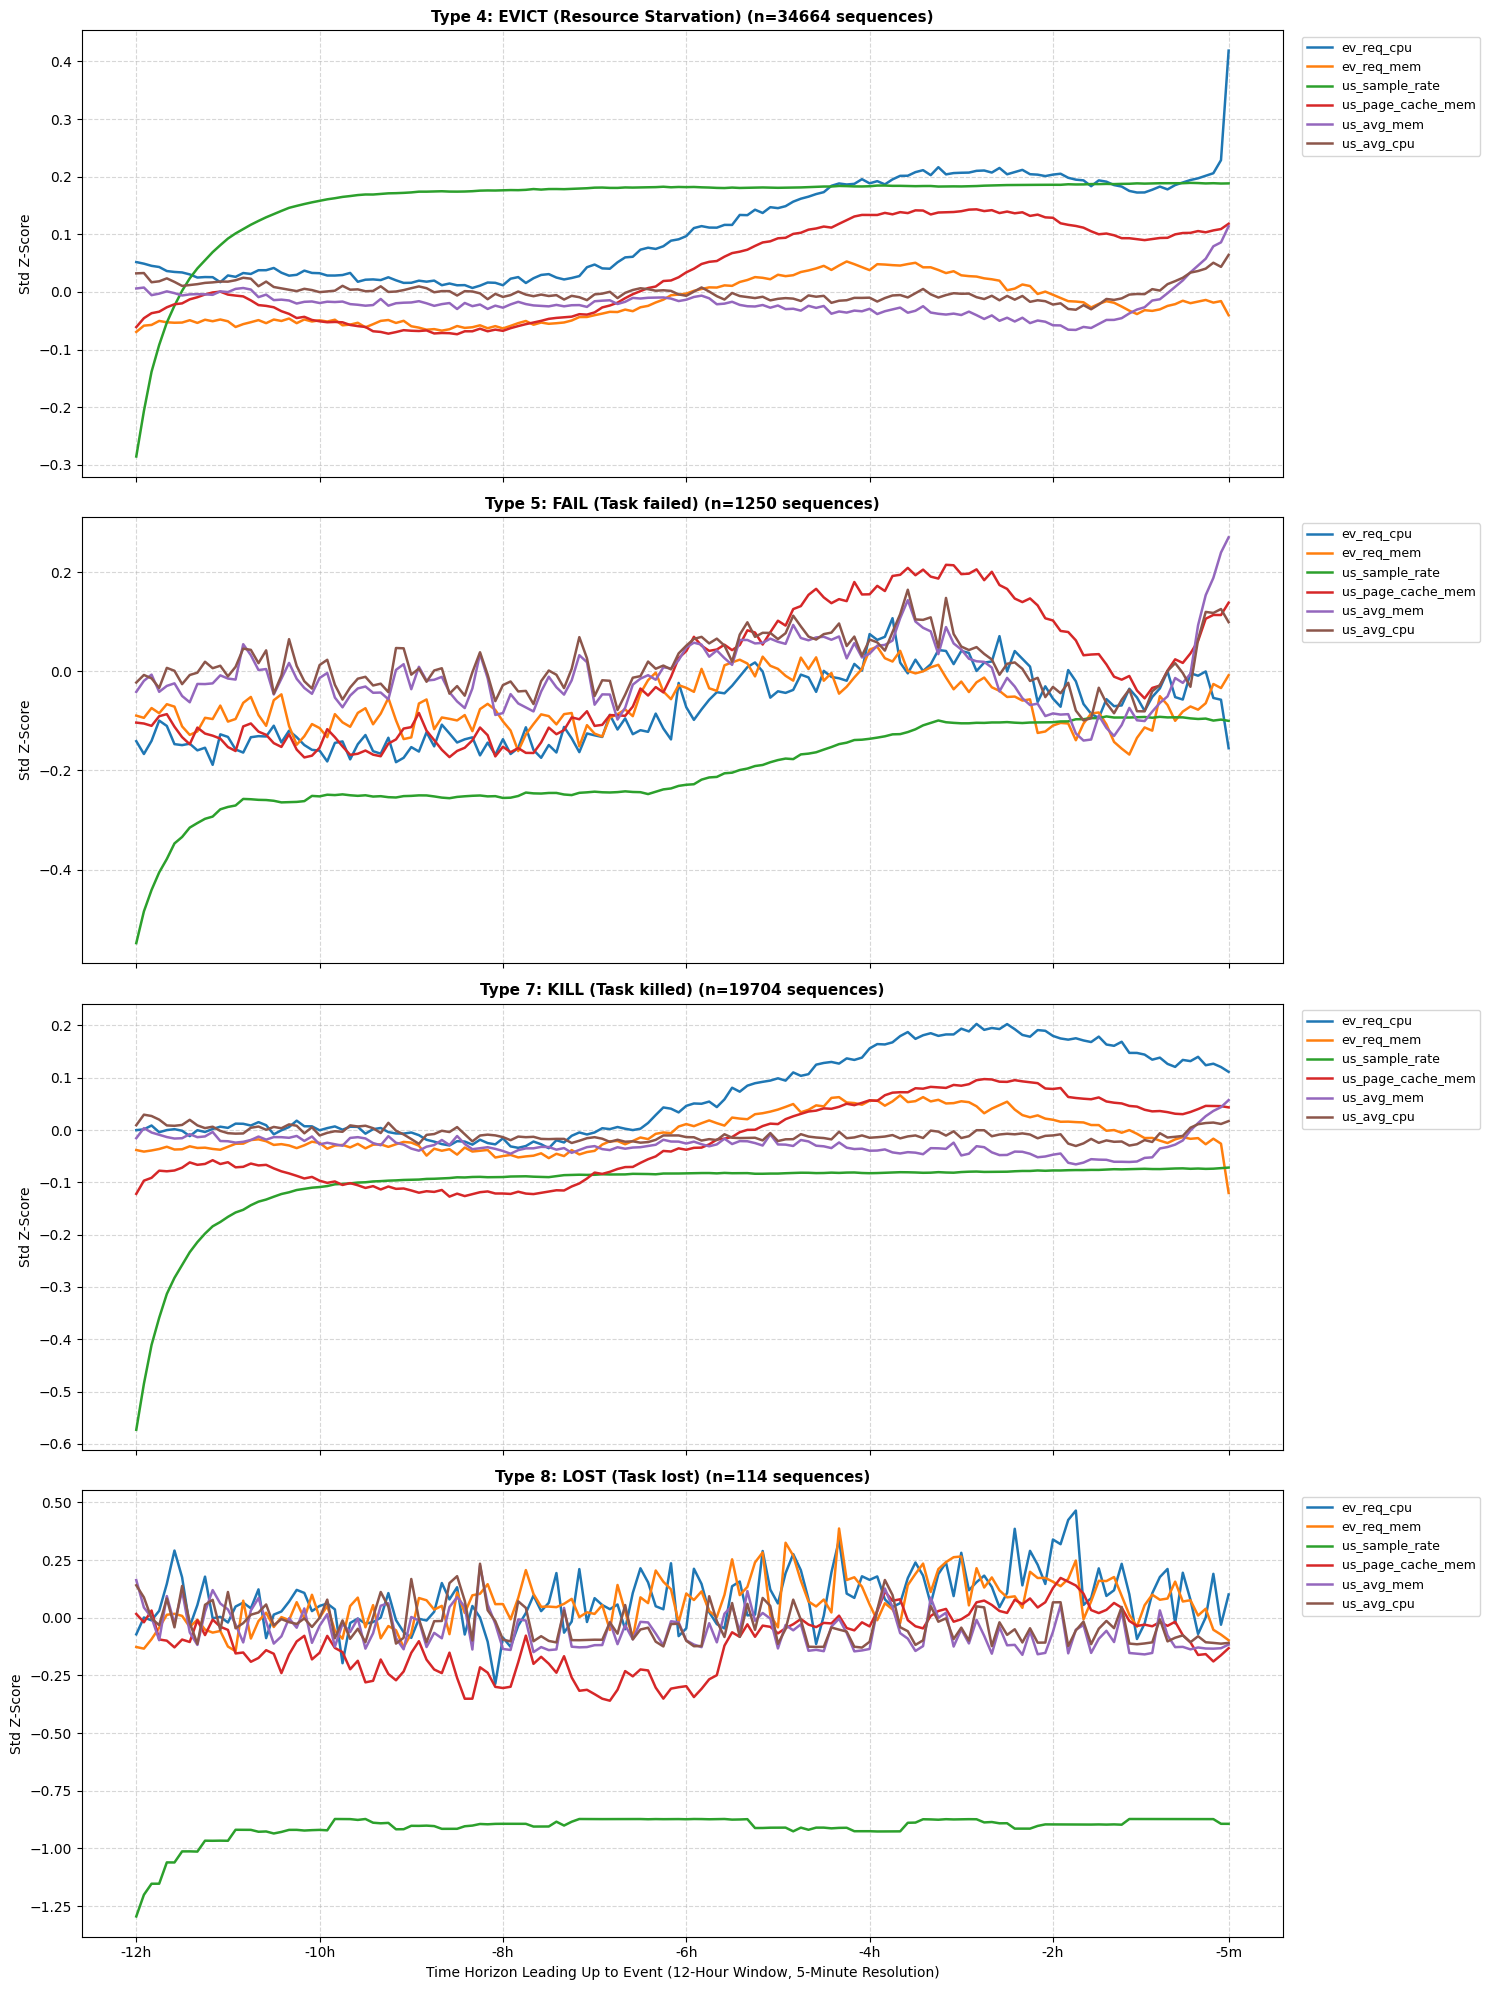

17026

In [28]:
print("1. Loading data for 12-hour diagnostics (preserving raw types)...")
event_schema = {
    "machine_id": pl.String, "time": pl.String, "type": pl.String,
    "priority": pl.String, "resource_request": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)])
}
usage_schema = {
    "machine_id": pl.String, "start_time": pl.String,
    "average_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "maximum_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "sample_rate": pl.Float64, "page_cache_memory": pl.Float64,
    "assigned_memory": pl.Float64, "cycles_per_instruction": pl.Float64
}

events_diag = (pl.scan_ndjson(event_path, n_rows=5000000, schema=event_schema)
          .select([
              pl.col("machine_id").cast(pl.Float64), pl.col("time").cast(pl.Float64),
              pl.col("type").cast(pl.Int32).alias("raw_type"),
              pl.col("priority").cast(pl.Int32).alias("priority_level"),
              pl.col("resource_request").struct.field("cpus").alias("ev_req_cpu"),
              pl.col("resource_request").struct.field("memory").alias("ev_req_mem"),
          ])
          .sort("time"))

usage_diag = (pl.scan_ndjson(usage_path, n_rows=5000000, schema=usage_schema)
         .select([
             pl.col("machine_id").cast(pl.Float64), pl.col("start_time").cast(pl.Float64).alias("time"),
             pl.col("sample_rate").alias("us_sample_rate"),
             pl.col("page_cache_memory").alias("us_page_cache_mem"),
             pl.col("average_usage").struct.field("cpus").alias("us_avg_cpu"),
             pl.col("average_usage").struct.field("memory").alias("us_avg_mem"),
             pl.col("maximum_usage").struct.field("cpus").alias("us_max_cpu"),
             pl.col("cycles_per_instruction").alias("us_cpi")
         ])
         .sort("time"))

df_diag_raw = events_diag.join_asof(usage_diag, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)

print("2. Resampling to 5-minute grid...")
df_diag_grid = df_diag_raw.with_columns(
    (pl.col("time") // 300_000_000).cast(pl.Int64).alias("time_bucket")
)

feature_names = [
    'ev_req_cpu', 
    'ev_req_mem', 
    'us_sample_rate', 
    'us_page_cache_mem', 
    'us_avg_mem',
    'us_avg_cpu',
]


# Dynamically aggregate all the new features
df_diag_grid = df_diag_grid.group_by(["machine_id", "time_bucket"]).agg([
    pl.col("raw_type").max()
] + [pl.col(f).mean() for f in feature_names]).sort(["machine_id", "time_bucket"]).fill_null(0.0)

def build_event_diagnostic_tensors_12h(df, window_size=144):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df.select(feature_names).to_numpy())
    
    df_scaled = df.with_columns([
        pl.Series(name=feature_names[i], values=scaled_data[:, i]) 
        for i in range(len(feature_names))
    ])

    X_diag, y_event_types = [], []
    
    for _, group in df_scaled.group_by("machine_id"):
        if len(group) <= window_size:
            continue
        
        feat_arr = group.select(feature_names).to_numpy().astype('float32')
        raw_types = group.select("raw_type").to_numpy().ravel()

        for i in range(len(group) - window_size):
            X_diag.append(feat_arr[i : i + window_size])
            y_event_types.append(raw_types[i + window_size])
            
    return np.array(X_diag), np.array(y_event_types)

print("3. Extracting 12-hour diagnostic sequences (144 steps)...")
X_all_12h, y_raw_12h = build_event_diagnostic_tensors_12h(df_diag_grid, window_size=144)
print(f"Extracted {X_all_12h.shape[0]} sequences of shape {X_all_12h.shape[1:]}")

print("4. Plotting trajectories...")
candidate_codes = {
    4: "Type 4: EVICT (Resource Starvation)",
    5: "Type 5: FAIL (Task failed)",
    7: "Type 7: KILL (Task killed)",
    8: "Type 8: LOST (Task lost)"
}

healthy_indices = np.where((y_raw_12h == 1) | (y_raw_12h == 6))[0]
rng = np.random.default_rng(42)

if len(healthy_indices) > 0:
    sampled_healthy_idx = rng.choice(healthy_indices, size=min(10000, len(healthy_indices)), replace=False)
    healthy_baseline_traj = np.mean(X_all_12h[sampled_healthy_idx], axis=0)
else:
    healthy_baseline_traj = np.zeros((144, len(feature_names)))

tick_positions = [0, 24, 48, 72, 96, 120, 143]
tick_labels = ["-12h", "-10h", "-8h", "-6h", "-4h", "-2h", "-5m"]

fig, axes = plt.subplots(len(candidate_codes), 1, figsize=(15, 20), sharex=True)

for ax, (code, label) in zip(axes, candidate_codes.items()):
    code_indices = np.where(y_raw_12h == code)[0]
    count = len(code_indices)
    
    if count == 0:
        ax.set_title(f"{label} (n=0 sequences)", fontsize=11, fontweight="bold")
        continue

    code_mean_traj = np.mean(X_all_12h[code_indices], axis=0)
    
    # Plot all 9 features so you can see exactly which ones crash before an event
    for i, feat in enumerate(feature_names):
        ax.plot(range(144), code_mean_traj[:, i], label=f"{feat}", linewidth=1.8)
    
    ax.set_title(f"{label} (n={count} sequences)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Std Z-Score")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # We move the legend out of the graph so it doesn't cover the lines
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, ncol=1)

axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_labels)
axes[-1].set_xlabel("Time Horizon Leading Up to Event (12-Hour Window, 5-Minute Resolution)")

plt.tight_layout()
plt.show()

import gc
del df_diag_raw, df_diag_grid
gc.collect()


1. Loading data for 24-hour diagnostics (preserving raw types)...


C:\Users\sabbu\AppData\Local\Temp\ipykernel_13452\3278916282.py:36: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_diag_raw = events_diag.join_asof(usage_diag, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)


2. Resampling to 5-minute grid...
3. Extracting 24-hour diagnostic sequences (288 steps)...
Extracted 9811 sequences of shape (288, 8)
4. Plotting trajectories...


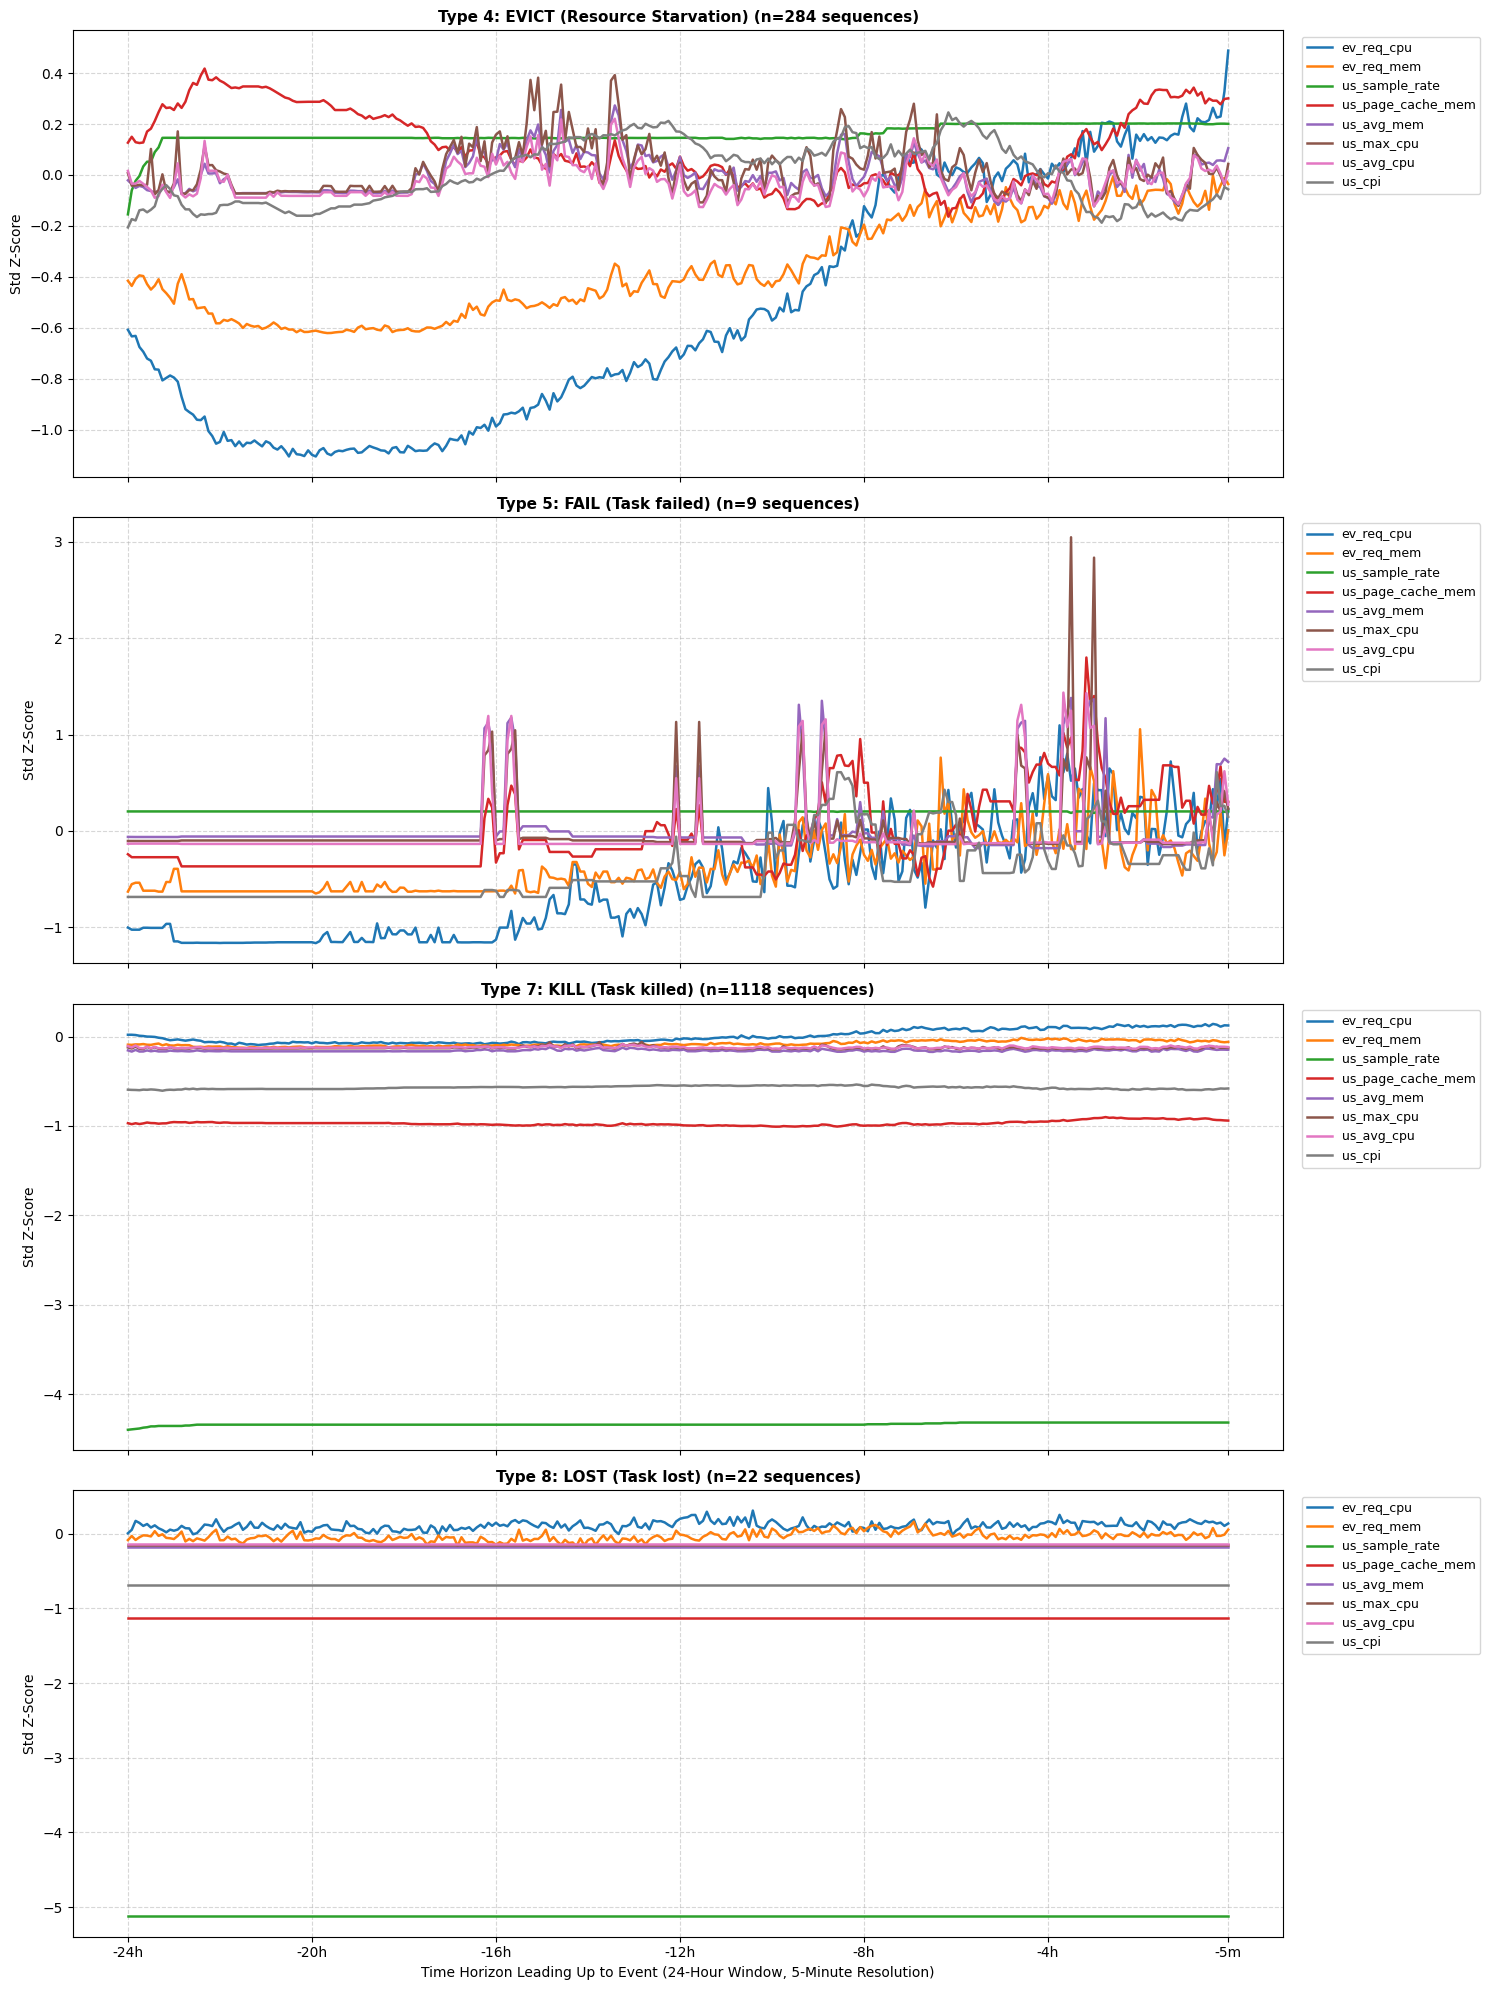

17588

In [ ]:
print("1. Loading data for 24-hour diagnostics (preserving raw types)...")
event_schema = {
    "machine_id": pl.String, "time": pl.String, "type": pl.String,
    "priority": pl.String, "resource_request": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)])
}
usage_schema = {
    "machine_id": pl.String, "start_time": pl.String,
    "average_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "maximum_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
    "sample_rate": pl.Float64, "page_cache_memory": pl.Float64,
    "assigned_memory": pl.Float64, "cycles_per_instruction": pl.Float64
}

events_diag = (pl.scan_ndjson(event_path, n_rows=5000000, schema=event_schema)
          .select([
              pl.col("machine_id").cast(pl.Float64), pl.col("time").cast(pl.Float64),
              pl.col("type").cast(pl.Int32).alias("raw_type"),
              pl.col("priority").cast(pl.Int32).alias("priority_level"),
              pl.col("resource_request").struct.field("cpus").alias("ev_req_cpu"),
              pl.col("resource_request").struct.field("memory").alias("ev_req_mem"),
          ])
          .sort("time"))

usage_diag = (pl.scan_ndjson(usage_path, n_rows=5000000, schema=usage_schema)
         .select([
             pl.col("machine_id").cast(pl.Float64), pl.col("start_time").cast(pl.Float64).alias("time"),
             pl.col("sample_rate").alias("us_sample_rate"),
             pl.col("page_cache_memory").alias("us_page_cache_mem"),
             pl.col("average_usage").struct.field("cpus").alias("us_avg_cpu"),
             pl.col("average_usage").struct.field("memory").alias("us_avg_mem"),
             pl.col("maximum_usage").struct.field("cpus").alias("us_max_cpu"),
             pl.col("cycles_per_instruction").alias("us_cpi")
         ])
         .sort("time"))

df_diag_raw = events_diag.join_asof(usage_diag, on="time", by="machine_id", strategy="backward").collect().fill_null(0.0)

print("2. Resampling to 5-minute grid...")
df_diag_grid = df_diag_raw.with_columns(
    (pl.col("time") // 300_000_000).cast(pl.Int64).alias("time_bucket")
)

feature_names = [
    'ev_req_cpu', 
    'ev_req_mem', 
    'us_sample_rate', 
    'us_page_cache_mem', 
    'us_avg_mem',
    'us_avg_cpu',
    'us_cpi'
]

# Dynamically aggregate all the new features
df_diag_grid = df_diag_grid.group_by(["machine_id", "time_bucket"]).agg([
    pl.col("raw_type").max()
] + [pl.col(f).mean() for f in feature_names]).sort(["machine_id", "time_bucket"]).fill_null(0.0)

def build_event_diagnostic_tensors_24h(df, window_size=288):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df.select(feature_names).to_numpy())
    
    df_scaled = df.with_columns([
        pl.Series(name=feature_names[i], values=scaled_data[:, i]) 
        for i in range(len(feature_names))
    ])

    X_diag, y_event_types = [], []
    
    for _, group in df_scaled.group_by("machine_id"):
        if len(group) <= window_size:
            continue
        
        feat_arr = group.select(feature_names).to_numpy().astype('float32')
        raw_types = group.select("raw_type").to_numpy().ravel()

        for i in range(len(group) - window_size):
            X_diag.append(feat_arr[i : i + window_size])
            y_event_types.append(raw_types[i + window_size])
            
    return np.array(X_diag), np.array(y_event_types)

print("3. Extracting 24-hour diagnostic sequences (288 steps)...")
X_all_24h, y_raw_24h = build_event_diagnostic_tensors_24h(df_diag_grid, window_size=288)
print(f"Extracted {X_all_24h.shape[0]} sequences of shape {X_all_24h.shape[1:]}")

print("4. Plotting trajectories...")
candidate_codes = {
    4: "Type 4: EVICT (Resource Starvation)",
    5: "Type 5: FAIL (Task failed)",
    7: "Type 7: KILL (Task killed)",
    8: "Type 8: LOST (Task lost)"
}

healthy_indices = np.where((y_raw_24h == 1) | (y_raw_24h == 6))[0]
rng = np.random.default_rng(42)

if len(healthy_indices) > 0:
    sampled_healthy_idx = rng.choice(healthy_indices, size=min(10000, len(healthy_indices)), replace=False)
    healthy_baseline_traj = np.mean(X_all_24h[sampled_healthy_idx], axis=0)
else:
    healthy_baseline_traj = np.zeros((288, len(feature_names)))

# Updated X-axis for a 24-hour window
tick_positions = [0, 48, 96, 144, 192, 240, 287]
tick_labels = ["-24h", "-20h", "-16h", "-12h", "-8h", "-4h", "-5m"]

fig, axes = plt.subplots(len(candidate_codes), 1, figsize=(15, 20), sharex=True)

for ax, (code, label) in zip(axes, candidate_codes.items()):
    code_indices = np.where(y_raw_24h == code)[0]
    count = len(code_indices)
    
    if count == 0:
        ax.set_title(f"{label} (n=0 sequences)", fontsize=11, fontweight="bold")
        continue

    code_mean_traj = np.mean(X_all_24h[code_indices], axis=0)
    
    # Plot all 8 features
    for i, feat in enumerate(feature_names):
        ax.plot(range(288), code_mean_traj[:, i], label=f"{feat}", linewidth=1.8)
    
    ax.set_title(f"{label} (n={count} sequences)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Std Z-Score")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, ncol=1)

axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_labels)
axes[-1].set_xlabel("Time Horizon Leading Up to Event (24-Hour Window, 5-Minute Resolution)")

plt.tight_layout()
plt.show()

import gc
del df_diag_raw, df_diag_grid
gc.collect()


In [12]:
import numpy as np
import polars as pl
import gc
import joblib
import lightgbm as lgb
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score


def run_ablation_harness_lgb(event_path, usage_path):
    label_sets = [[4, 7], [4, 5, 7]]
    window_size = 24  # 2h lookback (24 x 5min buckets)
    label_horizon = 12  # 1h forecast horizon

    # -----------------------------------------------------
    # THE 13 FEATURES (same as your main pipeline)
    # -----------------------------------------------------
    features = [
        'ev_req_cpu',
        'ev_priority',
        'ev_num_constraints',
        'ev_req_mem',
        'us_assigned_mem',
        'us_cpi',
        'us_page_cache_mem',
        'us_avg_mem',
        'us_avg_cpu',
        'us_mapi',
        'us_sample_rate',
        'us_cpu_dist_tail',
        'us_max_cpu'
    ]

    results = []

    # 1. Parameterized Data Loader (usage as base timeline -- correct join direction)
    def load_ablated_data(labels):
        print(f"Loading data with error labels: {labels}...")

        event_schema = {
            "machine_id": pl.String, "time": pl.String, "type": pl.String,
            "priority": pl.String, "missing_type": pl.String,
            "resource_request": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
            "constraint": pl.List(pl.Struct([]))
        }

        usage_schema = {
            "machine_id": pl.String, "start_time": pl.String,
            "average_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
            "maximum_usage": pl.Struct([pl.Field("cpus", pl.Float64), pl.Field("memory", pl.Float64)]),
            "random_sample_usage": pl.Struct([pl.Field("cpus", pl.Float64)]),
            "assigned_memory": pl.Float64, "page_cache_memory": pl.Float64,
            "cycles_per_instruction": pl.Float64, "memory_accesses_per_instruction": pl.Float64,
            "sample_rate": pl.Float64,
            "cpu_usage_distribution": pl.List(pl.Float64),
            "tail_cpu_usage_distribution": pl.List(pl.Float64)
        }

        events = (pl.scan_ndjson(event_path, schema=event_schema)
                  .select([
                      pl.col("machine_id").cast(pl.Float64),
                      pl.col("time").cast(pl.Float64),
                      pl.col("type").cast(pl.Int32).is_in(labels).cast(pl.Int8).alias("error_signal"),
                      pl.col("priority").cast(pl.Float64).alias("ev_priority"),
                      pl.col("resource_request").struct.field("cpus").alias("ev_req_cpu"),
                      pl.col("resource_request").struct.field("memory").alias("ev_req_mem"),
                      pl.col("constraint").list.len().cast(pl.Float64).alias("ev_num_constraints")
                  ])
                  .sort("time"))

        usage = (pl.scan_ndjson(usage_path, schema=usage_schema)
                 .select([
                     pl.col("machine_id").cast(pl.Float64),
                     pl.col("start_time").cast(pl.Float64).alias("time"),
                     pl.col("sample_rate").alias("us_sample_rate"),
                     pl.col("page_cache_memory").alias("us_page_cache_mem"),
                     pl.col("memory_accesses_per_instruction").alias("us_mapi"),
                     pl.col("average_usage").struct.field("cpus").alias("us_avg_cpu"),
                     pl.col("average_usage").struct.field("memory").alias("us_avg_mem"),
                     pl.col("maximum_usage").struct.field("cpus").alias("us_max_cpu"),
                     pl.col("cpu_usage_distribution").list.last().cast(pl.Float64).alias("us_cpu_dist_tail"),
                     pl.col("cycles_per_instruction").alias("us_cpi"),
                     pl.col("assigned_memory").alias("us_assigned_mem")
                 ])
                 .sort("time"))

        # usage is the base timeline -- events attach onto it (correct direction)
        return usage.join_asof(events, on="time", by="machine_id", strategy="backward").collect().drop_nulls()

    # 2. Time-Grid Resampler (Strict 5-Minute Buckets)
    def resample_to_time_grid(df):
        print("  -> Resampling to strict 5-minute time grid...")
        df = df.with_columns(
            (pl.col("time") // 300_000_000).cast(pl.Int64).alias("time_bucket")
        )
        resampled = df.group_by(["machine_id", "time_bucket"]).agg([
            pl.col("error_signal").max()
        ] + [pl.col(f).mean() for f in features]).sort(["machine_id", "time_bucket"])
        return resampled.fill_null(0.0)

    # 3. Sequence Extractor with Contiguity Check + full-window leakage guard
    def extract_sequences_from_df(df, window_size, horizon):
        groups = df.group_by("machine_id")
        X, y = [], []

        MAX_GAP = 24

        for _, group in groups:
            buckets = group.select("time_bucket").to_numpy().flatten()
            if len(buckets) == 0:
                continue

            vals = group.select(features).to_numpy()
            signals = group.select("error_signal").to_numpy().flatten()

            chunks = []
            current_chunk_buckets = [buckets[0]]
            current_chunk_vals = [vals[0]]
            current_chunk_signals = [signals[0]]

            for i in range(1, len(buckets)):
                gap = buckets[i] - buckets[i - 1]
                if gap > MAX_GAP:
                    chunks.append((current_chunk_buckets, current_chunk_vals, current_chunk_signals))
                    current_chunk_buckets = [buckets[i]]
                    current_chunk_vals = [vals[i]]
                    current_chunk_signals = [signals[i]]
                else:
                    current_chunk_buckets.append(buckets[i])
                    current_chunk_vals.append(vals[i])
                    current_chunk_signals.append(signals[i])

            chunks.append((current_chunk_buckets, current_chunk_vals, current_chunk_signals))

            for c_buckets, c_vals, c_signals in chunks:
                if len(c_buckets) == 0:
                    continue
                min_b = int(c_buckets[0])
                max_b = int(c_buckets[-1])

                if max_b - min_b + 1 < window_size + horizon:
                    continue

                length = max_b - min_b + 1
                if length > 100000:
                    continue

                dense_vals = np.zeros((length, len(features)), dtype='float32')
                dense_signals = np.zeros(length, dtype='int8')

                current_val = c_vals[0]
                idx = 0
                for b in range(length):
                    actual_bucket = min_b + b
                    if idx < len(c_buckets) and c_buckets[idx] == actual_bucket:
                        current_val = c_vals[idx]
                        dense_signals[b] = c_signals[idx]
                        idx += 1
                    dense_vals[b] = current_val

                # Leakage guard checks the FULL window_size, not a hardcoded sub-window
                for T in range(window_size, length - horizon):
                    if dense_signals[T - window_size: T].sum() == 0:
                        X.append(dense_vals[T - window_size: T])
                        y.append(1 if dense_signals[T: T + horizon].sum() > 0 else 0)

        return np.array(X), np.array(y)

    def split_df_by_machine_time(df, train_frac=0.70):
        train_rows, test_rows = [], []
        for _, group in df.group_by("machine_id"):
            group = group.sort("time_bucket")
            cut = int(len(group) * train_frac)
            train_rows.append(group.slice(0, cut))
            test_rows.append(group.slice(cut))
        return pl.concat(train_rows), pl.concat(test_rows)

    # Matches your main pipeline's balancing method exactly
    def undersample_to_ratio(X, y, target_healthy_ratio=0.50):
        fail_idx = np.where(y == 1)[0]
        healthy_idx = np.where(y == 0)[0]
        target_failure_ratio = 1.0 - target_healthy_ratio
        multiplier = target_healthy_ratio / target_failure_ratio
        target_healthy_count = int(len(fail_idx) * multiplier)
        target_healthy_count = min(target_healthy_count, len(healthy_idx))
        rng = np.random.default_rng(42)
        sampled_healthy_idx = rng.choice(healthy_idx, size=target_healthy_count, replace=False)
        keep_idx = np.concatenate([fail_idx, sampled_healthy_idx])
        rng.shuffle(keep_idx)
        return X[keep_idx], y[keep_idx]

    # Matches your main pipeline's tree-feature engineering exactly
    def engineer_tree_features(X_3d):
        last_step = X_3d[:, -1, :]
        mean_val = np.mean(X_3d, axis=1)
        delta_val = X_3d[:, -1, :] - X_3d[:, 0, :]
        std_val = np.std(X_3d, axis=1)
        max_val = np.max(X_3d, axis=1)
        return np.hstack([last_step, mean_val, delta_val, std_val, max_val])

    # Threshold sweep instead of one fixed cutoff -- picks the F1-best threshold per label set
    def sweep_best_threshold(y_true, y_prob, thresholds=None):
        if thresholds is None:
            thresholds = np.arange(0.10, 0.90, 0.025)
        best = {"threshold": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}
        for t in thresholds:
            y_pred_t = (y_prob > t).astype(int)
            f1 = f1_score(y_true, y_pred_t, zero_division=0)
            if f1 > best["f1"]:
                best = {
                    "threshold": float(t),
                    "precision": precision_score(y_true, y_pred_t, zero_division=0),
                    "recall": recall_score(y_true, y_pred_t, zero_division=0),
                    "f1": f1,
                }
        return best

    # --- Main Loop ---
    for labels in label_sets:
        df_raw = load_ablated_data(labels)
        df_grid = resample_to_time_grid(df_raw)
        df_train_grid, df_test_grid = split_df_by_machine_time(df_grid, train_frac=0.70)

        print("  -> Applying RobustScaler...")
        scaler = RobustScaler()

        df_train_scaled_vals = scaler.fit_transform(df_train_grid.select(features).to_numpy())
        df_train_grid = df_train_grid.with_columns([
            pl.Series(name=features[i], values=df_train_scaled_vals[:, i]) for i in range(len(features))
        ])

        df_test_scaled_vals = scaler.transform(df_test_grid.select(features).to_numpy())
        df_test_grid = df_test_grid.with_columns([
            pl.Series(name=features[i], values=df_test_scaled_vals[:, i]) for i in range(len(features))
        ])

        print(f"\n=== Testing Labels: {labels} | Window: {window_size} | Horizon: {label_horizon} ===")

        X_train_raw, y_train_raw = extract_sequences_from_df(df_train_grid, window_size, label_horizon)
        X_test, y_test = extract_sequences_from_df(df_test_grid, window_size, label_horizon)

        if len(X_train_raw) < 100 or len(X_test) < 20:
            print("  -> Not enough contiguous sequences generated, skipping.")
            continue

        print(f"  -> Raw train sequences: {len(X_train_raw)} | Positive rate: {y_train_raw.mean():.4f}")
        print(f"  -> Test sequences: {len(X_test)} | Positive rate: {y_test.mean():.4f}")

        X_train_bal, y_train_bal = undersample_to_ratio(X_train_raw, y_train_raw, target_healthy_ratio=0.50)
        print(f"  -> Balanced train sequences: {len(X_train_bal)} | Positive rate: {y_train_bal.mean():.4f}")

        X_train_tree = engineer_tree_features(X_train_bal)
        X_test_tree = engineer_tree_features(X_test)

        print("  -> Training LightGBM...")
        m = lgb.LGBMClassifier(random_state=42)
        m.fit(X_train_tree, y_train_bal)

        y_prob = m.predict_proba(X_test_tree)[:, 1]
        pr_auc = average_precision_score(y_test, y_prob)

        best = sweep_best_threshold(y_test, y_prob)

        # Save with a label-specific filename -- reusing fullscale_lgb_model_457.pkl
        # only for the [4,5,7] run, since that's the label set it was originally trained on.
        label_tag = "_".join(str(l) for l in labels)
        if labels == [4, 5, 7]:
            save_path = "fullscale_lgb_model_457.pkl"
        else:
            save_path = f"lgb_model_labels_{label_tag}.pkl"
        joblib.dump(m, save_path)
        print(f"  -> Saved model to '{save_path}'")

        print(f"  -> PR-AUC: {pr_auc:.4f}")
        print(f"  -> Best threshold: {best['threshold']:.3f} "
              f"(Precision={best['precision']:.4f}, Recall={best['recall']:.4f}, F1={best['f1']:.4f})")

        results.append({
            "Labels": str(labels),
            "Window": window_size,
            "PR_AUC": round(pr_auc, 4),
            "Best_Threshold": round(best["threshold"], 3),
            "Precision": round(best["precision"], 4),
            "Recall": round(best["recall"], 4),
            "F1_Score": round(best["f1"], 4),
        })

        del m, X_train_raw, y_train_raw, X_train_bal, y_train_bal, X_train_tree, X_test_tree
        gc.collect()

    if len(results) > 0:
        results_df = pl.DataFrame(results)
        print("\n" + "=" * 70)
        print("ABLATION HARNESS RESULTS (LightGBM, per-label-set tuned threshold)")
        print("=" * 70)
        print(results_df.sort("F1_Score", descending=True))
    else:
        print("\nERROR: No sequences were generated.")


run_ablation_harness_lgb(event_path, usage_path)

Loading data with error labels: [4, 7]...


C:\Users\sabbu\AppData\Local\Temp\ipykernel_22660\57112151.py:88: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  return usage.join_asof(events, on="time", by="machine_id", strategy="backward").collect().drop_nulls()


  -> Resampling to strict 5-minute time grid...
  -> Applying RobustScaler...

=== Testing Labels: [4, 7] | Window: 24 | Horizon: 12 ===
  -> Raw train sequences: 128334 | Positive rate: 0.3222
  -> Test sequences: 56748 | Positive rate: 0.3355
  -> Balanced train sequences: 82686 | Positive rate: 0.5000
  -> Training LightGBM...


C:\Users\sabbu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\sabbu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^

[LightGBM] [Info] Number of positive: 41343, number of negative: 41343
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015023 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14248
[LightGBM] [Info] Number of data points in the train set: 82686, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
  -> Saved model to 'lgb_model_labels_4_7.pkl'
  -> PR-AUC: 0.5699
  -> Best threshold: 0.425 (Precision=0.4022, Recall=0.8642, F1=0.5490)
Loading data with error labels: [4, 5, 7]...


C:\Users\sabbu\AppData\Local\Temp\ipykernel_22660\57112151.py:88: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  return usage.join_asof(events, on="time", by="machine_id", strategy="backward").collect().drop_nulls()


  -> Resampling to strict 5-minute time grid...
  -> Applying RobustScaler...

=== Testing Labels: [4, 5, 7] | Window: 24 | Horizon: 12 ===
  -> Raw train sequences: 122788 | Positive rate: 0.3271
  -> Test sequences: 56039 | Positive rate: 0.3378
  -> Balanced train sequences: 80338 | Positive rate: 0.5000
  -> Training LightGBM...
[LightGBM] [Info] Number of positive: 40169, number of negative: 40169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031308 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14322
[LightGBM] [Info] Number of data points in the train set: 80338, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
  -> Saved model to 'fullscale_lgb_model_457.pkl'
  -> PR-AUC: 0.5682
  -> Best threshold: 0.450 (Precision=0.4132, Recall=0.8223, F1=0.5500)

ABLATION HARNESS RESULTS (LightGBM, per-label-set tuned threshold)
shape: (2, 7)
┌

Test bench Models

In [6]:
def build_CNN_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, kernel_size=3, activation='relu'),
        layers.Dropout(0.2),
        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_LSTM_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_Hybrid_model(input_shape):
    """
    Upgraded Hybrid Model (Pure Accuracy).
    Uses deeper CNN feature extraction, a Bidirectional LSTM, 
    and Multi-Head Attention to capture complex temporal degradation patterns.
    """
    inputs = layers.Input(shape=input_shape)
    
    # 1. Feature Extraction (1D CNN)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # Reduce sequence length slightly to help the LSTM focus on higher-level features
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    # 2. Sequence Modeling (Bidirectional LSTM)
    # Bidirectional processing looks at the sequence in both directions
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.2)(x)
    
    # 3. Attention Mechanism (Multi-Head)
    # Vastly superior to standard Attention() for learning complex time dependencies
    attention_output = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
    
    # 4. Pooling & Output
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_GRU_model(input_shape):
    """
    GRU (Gated Recurrent Unit) is similar to LSTM but has fewer parameters. 
    It trains faster, uses less memory, and often achieves identical accuracy.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_ResNet1D_model(input_shape):
    """
    1D-ResNet: Uses skip connections (Add) to allow the model to train deeper 
    architectures without suffering from the vanishing gradient problem.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Initial Convolution
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    # Residual Block 1
    res = x
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([res, x])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    # Residual Block 2 (Double the filters)
    res = layers.Conv1D(128, kernel_size=1, padding='same')(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([res, x])
    x = layers.Activation('relu')(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_TCN_model(input_shape):
    """
    Temporal Convolutional Network: Uses causal and dilated convolutions 
    so the receptive field grows exponentially, capturing long-term memory like an LSTM but much faster.
    """
    inputs = layers.Input(shape=input_shape)
    x = inputs
    
    # Exponentially increasing dilation rates
    for dilation_rate in [1, 2, 4, 8]:
        res = layers.Conv1D(64, kernel_size=1, padding='same')(x)
        
        # 'causal' padding ensures the filter only looks at past data, never the future
        x = layers.Conv1D(64, kernel_size=3, padding='causal', dilation_rate=dilation_rate, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Conv1D(64, kernel_size=3, padding='causal', dilation_rate=dilation_rate)(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Add()([res, x])
        x = layers.Activation('relu')(x)
        
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model


def build_ResNet_Hybrid_model(input_shape):
    """
    1D-ResNet Hybrid: Replaces the basic CNN feature extractor with a 
    powerful 1D-ResNet block, followed by Bidirectional LSTM and Attention.
    """    
    inputs = layers.Input(shape=input_shape)
    
    # 1. ResNet Feature Extraction Block
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    # block 1
    res = x
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([res, x])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # block 2
    res = layers.Conv1D(128, kernel_size=1, padding='same')(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([res, x])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    # 2. Sequence Modeling
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.2)(x)
    
    # 3. Attention
    attention_output = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
    
    # 4. Pooling & Output
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_Deep_CNN_model(input_shape):
    """
    4-Layer Deep CNN: Stacks 4 convolutional layers to learn complex 
    hierarchical features while maintaining the blazing fast speed of a CNN.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # Layer 1
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        
        # Layer 2
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2), # Reduces the timeline length to speed up next layers
        
        # Layer 3 (Increase filters to learn more complex patterns)
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        
        # Layer 4
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        
        # Compress the sequence into a single vector
        layers.GlobalAveragePooling1D(),
        
        # Final classification
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model


In [7]:
def print_detailed_analysis(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = len(y_true)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    false_discovery_rate = fp / (fp + tp) if (fp + tp) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n" + "="*40)
    print(f"{name.upper()} PERFORMANCE REPORT")
    print("="*40)
    
    print(f"DETECTIONS")
    print(f"   True Positives (Caught Failures):  {tp:<8} ({(tp/total)*100:>5.2f}%)")
    print(f"   True Negatives (Correctly Healthy): {tn:<8} ({(tn/total)*100:>5.2f}%)")
    
    print(f"\nERRORS")
    print(f"   False Positives (False Alarms):    {fp:<8} ({(fp/total)*100:>5.2f}%)")
    print(f"   False Negatives (Missed Failures): {fn:<8} ({(fn/total)*100:>5.2f}%)")
    
    print(f"\nCORE METRICS")
    print(f"   F1 Score:  {f1:.4f}  (Balanced Accuracy)")
    print(f"   Precision: {precision:.4f}  (Reliability of Alarms)")
    print(f"   Recall:    {recall:.4f}  (Ability to Catch Failures)")
    print(f"   Specificity: {specificity:.4f}  (Baseline Stability)")
    
    print(f"\nACTIONABLE INSIGHTS")
    print(f"   False Discovery Rate: {false_discovery_rate:.2%}")
    print(f"   Insight: For every 100 alarms, {false_discovery_rate*100:.1f} are likely 'glitches'.")
    print("="*40)

In [8]:
def calculate_lead_time(y_true, y_pred, time_interval_mins=5):
    """
    Calculates how much warning (in minutes) the model gives.
    Assumes y_true and y_pred are sequences for a single machine.
    """
    lead_times = []
    
    for i in range(len(y_pred) - 1):
        if y_pred[i] == 1 and y_true[i] == 0:
            for look_ahead in range(i + 1, len(y_true)):
                if y_true[look_ahead] == 1:
                    time_diff = (look_ahead - i) * time_interval_mins
                    lead_times.append(time_diff)
                    break 
    
    if not lead_times:
        return 0
        
    return np.mean(lead_times)

In [ ]:
healthy_indices = np.where(y_test.ravel() == 0)[0]
failure_indices = np.where(y_test.ravel() == 1)[0]

node01_data = X_test[healthy_indices[0]]
node02_data = X_test[healthy_indices[1]]
node03_data = X_test[failure_indices[0]]
node04_data = X_test[failure_indices[1]]

np.save("node01_healthy.npy", node01_data)
np.save("node02_healthy.npy", node02_data)
np.save("node03_failure.npy", node03_data)
np.save("node04_failure.npy", node04_data)

print("Authentic dataset assets successfully exported!")

Authentic dataset assets successfully exported!


In [ ]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_scores = []

print("--- STARTING CROSS-VALIDATION ROBUSTNESS BENCHMARK ---")

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, y_tr = X[train_idx[:500000]], y[train_idx[:500000]]
    X_va, y_va = X[val_idx[:100000]], y[val_idx[:100000]]
    
    m_fold = build_CNN_model(X.shape[1:])
    m_fold.fit(X_tr, y_tr, epochs=3, batch_size=512, verbose=0)
    
    preds_fold = (m_fold.predict(X_va, verbose=0) > 0.5).astype(int)
    f1_fold = f1_score(y_va, preds_fold)
    fold_scores.append(f1_fold)
    print(f"Fold {fold + 1} F1 Score Stability: {f1_fold:.4f}")

print(f"\nMean Cross-Validation F1: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

--- STARTING CROSS-VALIDATION ROBUSTNESS BENCHMARK ---
Fold 1 F1 Score Stability: 0.6633
Fold 2 F1 Score Stability: 0.6452
Fold 3 F1 Score Stability: 0.6614

Mean Cross-Validation F1: 0.6566 (+/- 0.0081)


In [9]:
def test_industry_baselines(X_test, y_test):    
    # Static Threshold
    y_pred_static = (X_test[:, -1, 2] > 0.8) | (X_test[:, -1, 4] > 0.8)
    f1_static = f1_score(y_test, y_pred_static.astype(int))
    
    # EWMA Baseline
    alpha = 0.3
    ewma_val = np.zeros(X_test.shape[0])
    for t in range(X_test.shape[1]):
        ewma_val = alpha * X_test[:, t, 2] + (1 - alpha) * ewma_val
    
    y_pred_ewma = (ewma_val > 0.7)
    f1_ewma = f1_score(y_test, y_pred_ewma.astype(int))
    
    print(f"Static Threshold F1: {f1_static:.4f}")
    print(f"EWMA Moving Average F1: {f1_ewma:.4f}")

test_industry_baselines(X_test, y_test)

Static Threshold F1: 0.0560
EWMA Moving Average F1: 0.0000


In [ ]:
def engineer_tree_features(X_3d):
    # X_3d shape: (N, steps, num_features)
    # 1. Endpoint value
    last_step = X_3d[:, -1, :]
    # 2. Sequence mean
    mean_val = np.mean(X_3d, axis=1)
    # 3. Trajectory velocity (delta between start and end of window)
    delta_val = X_3d[:, -1, :] - X_3d[:, 0, :]
    # 4. Standard deviation (instability / volatility metric)
    std_val = np.std(X_3d, axis=1)
    # 5. Peak load
    max_val = np.max(X_3d, axis=1)
    
    return np.hstack([last_step, mean_val, delta_val, std_val, max_val])

X_train_tree = engineer_tree_features(X_train_60)
X_test_tree  = engineer_tree_features(X_test_60)
print("hello")

In [ ]:
# 1. Tree Feature Engineering (Summarizes the temporal window for XGBoost)
def engineer_tree_features(X_3d):
    last_step = X_3d[:, -1, :]
    mean_val  = np.mean(X_3d, axis=1)
    delta_val = X_3d[:, -1, :] - X_3d[:, 0, :]
    std_val   = np.std(X_3d, axis=1)
    max_val   = np.max(X_3d, axis=1)
    return np.hstack([last_step, mean_val, delta_val, std_val, max_val])

print("Preparing 60-Step features...")
X_train_tree_60 = engineer_tree_features(X_train_60)
X_test_tree_60  = engineer_tree_features(X_test_60)

print("Preparing 24-Step features (Sliced directly from 60-Step)...")
X_train_24 = X_train_60[:, -24:, :]
X_test_24  = X_test_60[:, -24:, :]
X_train_tree_24 = engineer_tree_features(X_train_24)
X_test_tree_24  = engineer_tree_features(X_test_24)

def train_and_evaluate_xgb(X_tr, y_tr, X_te, y_te, name):
    print(f"\n--- Training XGBoost on {name} ---")
    start_time = time.time()
    
    # Calculate scale_pos_weight dynamically based on training split
    pos_weight = (len(y_tr) - sum(y_tr)) / sum(y_tr)
    
    model = xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss', 
        scale_pos_weight=pos_weight,
        n_estimators=50,
        max_depth=4
    )
    
    model.fit(X_tr, y_tr)
    train_time = time.time() - start_time
    
    # Evaluate at a slightly elevated threshold to favor precision
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob > 0.55).astype(int)
    
    f1 = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    pr_auc = average_precision_score(y_te, y_prob)
    
    print(f"Training Time: {train_time:.1f} sec")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    
    return model

# 2. Run the Head-to-Head Benchmark
model_60 = train_and_evaluate_xgb(X_train_tree_60, y_train_60, X_test_tree_60, y_test_60, "60-Step Window (5 Hours)")
model_24 = train_and_evaluate_xgb(X_train_tree_24, y_train_60, X_test_tree_24, y_test_60, "24-Step Window (2 Hours)")

In [7]:
models_to_test = {
    #Commented out so they don't run again, saving you time!
    "XGBoost": "baseline_supervised",
    #"LightGBM": "baseline_supervised",
    #"Individual CNN": build_CNN_model,
    # "1D-ResNet": build_ResNet1D_model,
    # "TCN": build_TCN_model,
    # "Individual LSTM": build_LSTM_model,
    # "Individual GRU": build_GRU_model,
    # "Hybrid": build_Hybrid_model,
    # "Deep CNN": build_Deep_CNN_model,
    # "ResNet-Hybrid": build_ResNet_Hybrid_model
}
results_file = "model_results.json"
# load existing results as to not overright any.
results = {}
if os.path.exists(results_file):
    with open(results_file, 'r') as f:
        try:
            results = json.load(f)
            print(f"Loaded {len(results)} existing model scores from {results_file}")
        except json.JSONDecodeError:
            pass
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

for name, factory in models_to_test.items():
    print(f"\n--- Training {name} ---")
    
    start_time = time.time()
    
    if isinstance(factory, str):
        if factory == "baseline_supervised":
            if name == "XGBoost":
                pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
                m = xgb.XGBClassifier(random_state=42, use_label_encoder=False, 
                                      eval_metric='logloss', scale_pos_weight=pos_weight)
            elif name == "LightGBM":
                m = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
            else:
                raise ValueError(f"Unknown baseline: {name}")
            
            m.fit(X_train_flat, y_train)
            if name in ["XGBoost", "LightGBM"]:
                y_prob = m.predict_proba(X_test_flat)[:, 1]
                    
                if name == "XGBoost":
                    m.save_model("fullscale_xgb_model_457.json")
                    print("Saved XGBoost model to 'fullscale_xgb_model_457.json'")
                elif name == "LightGBM":
                    joblib.dump(m, 'fullscale_lgb_model_457.pkl')
                    print("Saved LightGBM model to 'fullscale_lgb_model_457.pkl'")
            y_pred = m.predict(X_test_flat)
        elif factory == "baseline_unsupervised":
            if name == "Isolation Forest":
                m = IsolationForest(random_state=42)
                m.fit(X_train_flat)
                y_pred_iso = m.predict(X_test_flat)
                y_pred = np.where(y_pred_iso == -1, 1, 0)
            else:
                raise ValueError(f"Unknown unsupervised baseline: {name}")
    else:
        classes = np.unique(y_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weights = dict(zip(classes, weights))
        
        print(f"  -> Training on {len(X_train)} unbroken sequences...")
        print(f"  -> Applying Class Weights: {class_weights}")
        
        m = factory(X_train.shape[1:])
        m.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1, validation_split=0.1, class_weight=class_weights)
        y_pred = (m.predict(X_test) > 0.5).astype(int)
        
    end_time = time.time()
    training_duration = end_time - start_time
    
    score = f1_score(y_test, y_pred)
    
    # Save/Append both metrics safely
    results[name] = {
        "f1_score": float(score),
        "training_time_seconds": round(training_duration, 2)
    }
    
    print(f"{name} F1 Score on Test Set: {score:.4f} (Took {training_duration:.2f} seconds)")
    
    if not isinstance(factory, str):
        del m
        tf.keras.backend.clear_session()
        gc.collect()

# Save appended results back to the file
with open(results_file, 'w') as f:
    json.dump(results, f, indent=4)
print("\n" + "="*40)
print(f"RESULTS SAFELY APPENDED TO: {os.path.abspath(results_file)}")
print("="*40)

Loaded 12 existing model scores from model_results.json

--- Training XGBoost ---


C:\Users\sabbu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [13:45:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved XGBoost model to 'fullscale_xgb_model_457.json'
XGBoost F1 Score on Test Set: 0.3670 (Took 97.40 seconds)

RESULTS SAFELY APPENDED TO: c:\Users\sabbu\OneDrive\Documents\Git\System-Degradation-Predictor\model_results.json


In [ ]:
extended_early_stop = EarlyStopping( monitor='val_loss', patience=5, restore_best_weights=True)

all_predictions = {}
optimized_results = {}

top_models = {
    #"Individual CNN": build_CNN_model,
    "Hybrid": build_Hybrid_model
}

for name, factory in top_models.items():
    print(f"\n--- Deep Training {name} ---")
    m = factory(X_train.shape[1:])
    
    history = m.fit(
        X_train, y_train, 
        epochs=50,           
        batch_size=512,
        verbose=1, 
        validation_split=0.1,
        callbacks=[extended_early_stop]
    )
    
    preds = (m.predict(X_test) > 0.5).astype(int)
    all_predictions[name] = preds

    score = f1_score(y_test, preds)
    optimized_results[name] = score
    print(f"{name} Final F1: {score:.4f}")


--- Deep Training Hybrid ---
Epoch 1/50
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 741s 119ms/step - AUC: 0.7985 - loss: 0.5262 - val_AUC: 0.8486 - val_loss: 0.4745
Epoch 2/50
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 751s 121ms/step - AUC: 0.8707 - loss: 0.4423 - val_AUC: 0.8815 - val_loss: 0.4251
Epoch 3/50
1953/6197 ━━━━━━━━━━━━━━━━━━━━ 8:32 121ms/step - AUC: 0.8821 - loss: 0.4241

KeyboardInterrupt: 

In [ ]:
print_detailed_analysis("Individual CNN", y_test, all_predictions["Individual CNN"])
print_detailed_analysis("Hybrid", y_test, all_predictions["Hybrid"])

In [ ]:
avg_lead_hybrid = calculate_lead_time(y_test.ravel(), all_predictions["Hybrid"].ravel())
print(f"Average Lead-Time Warning(Hybrid): {avg_lead_hybrid:.2f} minutes")

avg_lead_cnn = calculate_lead_time(y_test.ravel(), all_predictions["Individual CNN"].ravel())
print(f"Average Lead-Time Warning(Individual CNN): {avg_lead_cnn:.2f} minutes")

Final Model test

In [ ]:
num_healthy = np.sum(y == 0)
num_failures = np.sum(y == 1)
total_samples = len(y)

print(f"Label Balance Summary: Healthy = {num_healthy} | Failures = {num_failures}")

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

weight_for_0 = (1 / num_healthy) * (total_samples / 2.0)
weight_for_1 = (1 / num_failures) * (total_samples / 2.0)

class_weights = {0: weight_for_0, 1: weight_for_1}

balanced_cnn = build_CNN_model(X_train.shape[1:])
balanced_cnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.1,
    class_weight=class_weights, 
    callbacks=[early_stop],
    verbose=1
)

balanced_preds = (balanced_cnn.predict(X_test) > 0.5).astype(int)
print_detailed_analysis("Balanced CNN", y_test, balanced_preds)
avg_lead_balanced = calculate_lead_time(y_test.ravel(), balanced_preds.ravel())
print(f"Average Lead-Time Warning(Balanced CNN): {avg_lead_balanced:.2f} minutes")

Label Balance Summary: Healthy = 2538881 | Failures = 1867810
Epoch 1/10
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 104s 16ms/step - AUC: 0.8151 - loss: 0.5259 - val_AUC: 0.8399 - val_loss: 0.4933
Epoch 2/10
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 97s 16ms/step - AUC: 0.8426 - loss: 0.4917 - val_AUC: 0.8529 - val_loss: 0.4824
Epoch 3/10
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 100s 16ms/step - AUC: 0.8537 - loss: 0.4757 - val_AUC: 0.8625 - val_loss: 0.4615
Epoch 4/10
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 99s 16ms/step - AUC: 0.8595 - loss: 0.4671 - val_AUC: 0.8665 - val_loss: 0.4588
Epoch 5/10
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 100s 16ms/step - AUC: 0.8622 - loss: 0.4629 - val_AUC: 0.8685 - val_loss: 0.4594
Epoch 6/10
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 102s 16ms/step - AUC: 0.8641 - loss: 0.4600 - val_AUC: 0.8692 - val_loss: 0.4518
Epoch 7/10
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 106s 17ms/step - AUC: 0.8655 - loss: 0.4578 - val_AUC: 0.8708 - val_loss: 0.4517
Epoch 8/10
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 106s 17ms/step - AUC: 0.8668 - loss: 

In [ ]:
import os

try:
    balanced_cnn.save("final_balanced_cnn.keras")
    print("SUCCESS: 'final_balanced_cnn.keras' has been saved!")
    print(f"File location: {os.path.abspath('final_balanced_cnn.keras')}")
except NameError:
    print("ERROR: Could not find a model named 'balanced_cnn'.")
    print("Please check your notebook cells above to see what variable name you used for your final model.")
except Exception as e:
    print(f"An error occurred while saving: {e}")

ERROR: Could not find a model named 'balanced_cnn'.
Please check your notebook cells above to see what variable name you used for your final model.


In [ ]:
import os

# Identify your hybrid model variable (change 'hybrid_model' to 'm' if you kept the loop variable)
target_model = globals().get("hybrid_model", globals().get("m", None))

save_path = "final_hybrid_model.keras"

if target_model is not None:
    try:
        target_model.save(save_path)
        print(f"SUCCESS: Hybrid model saved to: {os.path.abspath(save_path)}")
    except Exception as e:
        print(f"Error saving hybrid model: {e}")
else:
    print("ERROR: Neither 'hybrid_model' nor 'm' was found in memory.")
    print("If you named your model differently, replace target_model with your variable name.")


In [ ]:
from tensorflow.keras.models import load_model

# Load and test
loaded_hybrid = load_model("final_hybrid_model.keras")
print("Model loaded successfully!")
loaded_hybrid.summary()
